In [1]:
# =============================================================================
# 22_test_sentinel2_scm_multiple_outcomes_validation.ipynb
#
# PURPOSE
# =============================================================================
#
# Pre-hurricane holdout validation for Sentinel-2 imagery using:
#
#     Synthetic Control with Multiple Outcomes
#
# following the logic of Tian, Lee, and Panchenko and the supplied
# COVID empirical implementation.
#
#
# IMPORTANT: SATELLITE IMAGERY AS MULTIPLE OUTCOMES
# =============================================================================
#
# Each Sentinel-2 biweekly TIFF has 8 bands/features:
#
#     B2
#     B3
#     B4
#     B8
#     B11
#     B12
#     NDVI
#     NDWI
#
# For each site × period × band, this notebook extracts the SPATIAL MEAN
# of the raster band.
#
# Therefore:
#
#     one site × one period
#
# becomes an 8-outcome vector.
#
# The 8 bands are treated as the multiple outcomes in the SCM matching
# problem.
#
#
# SAMPLE
# =============================================================================
#
# Fixed sample from Notebook 10 / Notebook 12:
#
#     10 treatment sites
#     5 matched counterfactual sites per treatment
#
# For each treatment site, SCM estimates:
#
#     5 donor weights
#
# The weights are NOT band-specific.
#
# One common vector of 5 weights is estimated jointly from the 8 bands.
#
#
# VALIDATION DESIGNS
# =============================================================================
#
# EXPERIMENT 1: SINGLE-PERIOD MULTIPLE-OUTCOME SCM
#
#     before_P09 = weight estimation
#     before_P10 = held-out validation
#
# Weight estimation uses:
#
#     1 period × 8 bands = up to 8 matching variables
#
# Because only one period is used, temporal demeaning is NOT possible.
# The P09 band values are standardized only by their cross-sectional
# standard deviations across the treated site + 5 donors.
#
#
# EXPERIMENT 2: MULTI-PERIOD × MULTIPLE-OUTCOME SCM
#
#     before_P01-before_P09 = weight estimation
#     before_P10            = held-out validation
#
# Weight estimation uses:
#
#     9 periods × 8 bands = up to 72 matching variables
#
# This follows the supplied COVID script:
#
#     1. Within each site and each band, subtract the P01-P09 mean.
#     2. Stack all period × band observations.
#     3. Remove cells with missing values for treated or any donor.
#     4. Remove cells with zero cross-sectional SD.
#     5. Standardize each cell by its cross-sectional SD.
#     6. Build V so each band receives equal TOTAL weight.
#     7. Estimate one common 5-donor weight vector.
#
#
# SCM OBJECTIVE
# =============================================================================
#
# For treated vector Zi and donor matrix ZJ:
#
#     W_hat
#       = argmin_W
#         (Zi - ZJ.T @ W)' V (Zi - ZJ.T @ W)
#
# subject to:
#
#     sum(W) = 1
#     W_j >= 0
#
#
# NO EFFECT ESTIMATION
# =============================================================================
#
# This notebook ONLY:
#
#     - extracts Sentinel-2 image features
#     - estimates SCM weights
#     - validates weights using P10
#     - reports validation errors and RMSE/MAE
#
# It does NOT estimate post-hurricane treatment effects.
#
#
# OUTPUT
# =============================================================================
#
# datasets/
# └── test/
#     └── scm_mutiple_outcomes/
#         ├── 01_sentinel2_feature_panel.csv
#         ├── 02_exp1_p09_weights.csv
#         ├── 03_exp1_p10_validation.csv
#         ├── 04_exp1_validation_summary.csv
#         ├── 05_exp2_p01_p09_weights.csv
#         ├── 06_exp2_p10_validation.csv
#         ├── 07_exp2_validation_summary.csv
#         ├── 08_weight_diagnostics.csv
#         ├── 09_experiment_comparison.csv
#         ├── sentinel2_scm_multiple_outcomes.xlsx
#         └── figures/
#
# =============================================================================

In [2]:
# =============================================================================
# 1. PACKAGES
# =============================================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import rasterio

from scipy.optimize import minimize

import matplotlib.pyplot as plt


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


print(
    "Packages loaded successfully."
)

Packages loaded successfully.


In [3]:
# =============================================================================
# 2. PROJECT PATHS
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)


FINALS_DIR = (
    BASE_DIR /
    "finals"
)


BIWEEKLY_DIR = (
    FINALS_DIR /
    "biweekly_datasets"
)


BIWEEKLY_QUALITY_FILE = (
    BIWEEKLY_DIR /
    "biweekly_image_quality.csv"
)


SELECTED_SAMPLE_FILE = (
    FINALS_DIR /
    "daily_datasets" /
    "selected_site_sample.csv"
)


TEST_DIR = (
    BASE_DIR /
    "test"
)


OUTPUT_DIR = (
    TEST_DIR /
    "scm_mutiple_outcomes"
)


FIGURE_DIR = (
    OUTPUT_DIR /
    "figures"
)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print(
    "\nOutput directory:"
)


print(
    OUTPUT_DIR
)

# =============================================================================
# Output files
# =============================================================================

FEATURE_PANEL_FILE = (
    OUTPUT_DIR /
    "01_sentinel2_feature_panel.csv"
)

WEIGHTS_FILE = (
    OUTPUT_DIR /
    "02_scm_weights.csv"
)

VALIDATION_FILE = (
    OUTPUT_DIR /
    "03_p10_validation.csv"
)

VALIDATION_SUMMARY_FILE = (
    OUTPUT_DIR /
    "04_validation_summary.csv"
)

COMPARISON_FILE = (
    OUTPUT_DIR /
    "05_experiment_comparison.csv"
)

EXCEL_FILE = (
    OUTPUT_DIR /
    "scm_multiple_outcomes_results.xlsx"
)

FIGURE_DIR = (
    OUTPUT_DIR /
    "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_DIR = (
    BASE_DIR /
    "test" /
    "scm_mutiple_outcomes"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


Output directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/scm_mutiple_outcomes


In [4]:
# =============================================================================
# 3. OUTPUT FILES
# =============================================================================

FEATURE_PANEL_FILE = (
    OUTPUT_DIR /
    "01_sentinel2_feature_panel.csv"
)


EXP1_WEIGHTS_FILE = (
    OUTPUT_DIR /
    "02_exp1_p09_weights.csv"
)


EXP1_VALIDATION_FILE = (
    OUTPUT_DIR /
    "03_exp1_p10_validation.csv"
)


EXP1_SUMMARY_FILE = (
    OUTPUT_DIR /
    "04_exp1_validation_summary.csv"
)


EXP2_WEIGHTS_FILE = (
    OUTPUT_DIR /
    "05_exp2_p01_p09_weights.csv"
)


EXP2_VALIDATION_FILE = (
    OUTPUT_DIR /
    "06_exp2_p10_validation.csv"
)


EXP2_SUMMARY_FILE = (
    OUTPUT_DIR /
    "07_exp2_validation_summary.csv"
)


DIAGNOSTICS_FILE = (
    OUTPUT_DIR /
    "08_weight_diagnostics.csv"
)


COMPARISON_FILE = (
    OUTPUT_DIR /
    "09_experiment_comparison.csv"
)


EXCEL_FILE = (
    OUTPUT_DIR /
    "sentinel2_scm_multiple_outcomes.xlsx"
)

In [5]:
# =============================================================================
# 4. SENSOR AND OUTCOME DEFINITIONS
# =============================================================================

SENSOR = (
    "sentinel2"
)


SENSOR_BANDS = [

    "B2",

    "B3",

    "B4",

    "B8",

    "B11",

    "B12",

    "NDVI",

    "NDWI",

]


FEATURE_COLUMNS = [

    f"mean_{band}"

    for band
    in SENSOR_BANDS

]

In [6]:
# =============================================================================
# 5. VALIDATION DESIGNS
# =============================================================================

EXP1_TRAIN_PERIODS = [
    9,
]


EXP1_TEST_PERIOD = (
    10
)


EXP2_TRAIN_PERIODS = list(
    range(
        1,
        10,
    )
)


EXP2_TEST_PERIOD = (
    10
)


print(
    "\nValidation designs:"
)


print(
    "Experiment 1: P09 -> P10"
)


print(
    "Experiment 2: P01-P09 -> P10"
)


Validation designs:
Experiment 1: P09 -> P10
Experiment 2: P01-P09 -> P10


In [7]:
# =============================================================================
# 6. NUMERICAL SETTINGS
# =============================================================================

SD_TOL = (
    1e-10
)


WEIGHT_TOL = (
    1e-10
)


OPT_FTOL = (
    1e-12
)


OPT_MAXITER = (
    5000
)

In [8]:
# =============================================================================
# 7. PERIOD HELPER
# =============================================================================

def sequential_period(
    period_id,
):

    period_id = str(
        period_id
    )


    if period_id.startswith(
        "before_"
    ):

        return int(
            period_id
            .split(
                "P"
            )[-1]
        )


    if period_id.startswith(
        "after_"
    ):

        return (
            10
            +
            int(
                period_id
                .split(
                    "P"
                )[-1]
            )
        )


    return np.nan

In [9]:
# =============================================================================
# 8. VERIFY INPUT FILES
# =============================================================================

for file_path in [

    BIWEEKLY_QUALITY_FILE,

    SELECTED_SAMPLE_FILE,

]:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Required file missing:\n{file_path}"
        )


print(
    "\nRequired input files found."
)


Required input files found.


In [10]:
# =============================================================================
# 9. LOAD FIXED SAMPLE
# =============================================================================

sample = pd.read_csv(
    SELECTED_SAMPLE_FILE
)


required_sample_columns = [

    "site_id",

    "group",

    "matched_treatment_site_id",

    "control_rank",

]


missing_sample_columns = [

    column

    for column
    in required_sample_columns

    if column not in sample.columns

]


if missing_sample_columns:

    raise ValueError(
        "selected_site_sample.csv is missing columns:\n"
        +
        str(
            missing_sample_columns
        )
    )


sample[
    "site_id"
] = (
    sample[
        "site_id"
    ]
    .astype(str)
)


sample[
    "group"
] = (
    sample[
        "group"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)


sample[
    "matched_treatment_site_id"
] = (
    sample[
        "matched_treatment_site_id"
    ]
    .astype(str)
)


sample[
    "control_rank"
] = pd.to_numeric(
    sample[
        "control_rank"
    ],
    errors=
        "coerce",
)


# Treatment rows map to themselves.
treatment_mask = (
    sample[
        "group"
    ]
    ==
    "treatment"
)


sample.loc[
    treatment_mask,
    "matched_treatment_site_id",
] = (
    sample.loc[
        treatment_mask,
        "site_id",
    ]
)


sample = (
    sample
    .drop_duplicates(
        subset=[
            "site_id",
            "group",
        ]
    )
    .reset_index(
        drop=True
    )
)


treatment_sites = (
    sample
    .loc[
        sample[
            "group"
        ]
        ==
        "treatment",
        "site_id",
    ]
    .drop_duplicates()
    .astype(str)
    .tolist()
)


print(
    "\nTreatment sites:",
    len(
        treatment_sites
    )
)


Treatment sites: 10


In [11]:
# =============================================================================
# 10. DONOR HELPER
# =============================================================================

def get_donor_ids(
    treatment_site,
):

    donor_ids = (
        sample
        .loc[
            (
                sample[
                    "group"
                ]
                ==
                "counterfactual"
            )
            &
            (
                sample[
                    "matched_treatment_site_id"
                ]
                ==
                str(
                    treatment_site
                )
            )
        ]
        .sort_values(
            "control_rank"
        )[
            "site_id"
        ]
        .astype(str)
        .tolist()
    )


    if len(
        donor_ids
    ) != 5:

        print(
            "\nWARNING:"
        )


        print(
            treatment_site,
            "has",
            len(
                donor_ids
            ),
            "matched donors instead of 5."
        )


    return donor_ids

In [12]:
# =============================================================================
# 11. LOAD SENTINEL-2 INVENTORY
#
# Only BEFORE P01-P10 are needed.
# =============================================================================

quality = pd.read_csv(
    BIWEEKLY_QUALITY_FILE
)


quality[
    "site_id"
] = (
    quality[
        "site_id"
    ]
    .astype(str)
)


quality[
    "group"
] = (
    quality[
        "group"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)


quality[
    "sensor"
] = (
    quality[
        "sensor"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)


quality[
    "sequential_period"
] = (
    quality[
        "period_id"
    ]
    .apply(
        sequential_period
    )
)


selected_site_ids = set(
    sample[
        "site_id"
    ]
    .astype(str)
)


quality = (
    quality
    .loc[
        (
            quality[
                "site_id"
            ]
            .isin(
                selected_site_ids
            )
        )
        &
        (
            quality[
                "sensor"
            ]
            ==
            SENSOR
        )
        &
        (
            quality[
                "period"
            ]
            ==
            "before"
        )
        &
        (
            quality[
                "sequential_period"
            ]
            .isin(
                range(
                    1,
                    11,
                )
            )
        )
    ]
    .copy()
)


print(
    "\nSentinel-2 BEFORE P01-P10 inventory rows:",
    len(
        quality
    )
)


Sentinel-2 BEFORE P01-P10 inventory rows: 600


In [13]:
# =============================================================================
# 12. IMAGE FEATURE EXTRACTION
#
# Each GeoTIFF is:
#
#     band × row × column
#
# For every raster band, calculate the spatial mean over finite pixels.
#
# This converts an image into 8 scalar outcomes:
#
#     mean_B2
#     mean_B3
#     mean_B4
#     mean_B8
#     mean_B11
#     mean_B12
#     mean_NDVI
#     mean_NDWI
#
# =============================================================================

def extract_image_features(
    file_path,
):

    output = {

        feature:
            np.nan

        for feature
        in FEATURE_COLUMNS

    }


    if pd.isna(
        file_path
    ):

        return output


    file_path = Path(
        str(
            file_path
        )
    )


    if not file_path.exists():

        return output


    try:

        with rasterio.open(
            file_path
        ) as src:

            data = (
                src
                .read(
                    masked=True
                )
                .astype(
                    "float32"
                )
                .filled(
                    np.nan
                )
            )


        if (
            data.shape[
                0
            ]
            !=
            len(
                SENSOR_BANDS
            )
        ):

            raise ValueError(
                f"{file_path}: expected "
                f"{len(SENSOR_BANDS)} bands, "
                f"found {data.shape[0]}."
            )


        for band_index, band_name in enumerate(
            SENSOR_BANDS
        ):

            band_array = (
                data[
                    band_index
                ]
            )


            finite = np.isfinite(
                band_array
            )


            output[
                f"mean_{band_name}"
            ] = (
                float(
                    np.mean(
                        band_array[
                            finite
                        ]
                    )
                )

                if finite.any()

                else np.nan
            )


    except Exception as error:

        print(
            "\nWARNING: image feature extraction failed:"
        )


        print(
            file_path
        )


        print(
            error
        )


    return output

In [14]:
# =============================================================================
# 13. EXTRACT SENTINEL-2 P01-P10 FEATURES
# =============================================================================

feature_records = []


print(
    "\nExtracting Sentinel-2 image features..."
)


for row_number, (_, row) in enumerate(
    quality.iterrows(),
    start=1,
):

    image_features = (
        extract_image_features(
            row[
                "output_file"
            ]
        )
    )


    record = {

        "site_id":
            str(
                row[
                    "site_id"
                ]
            ),

        "group":
            row[
                "group"
            ],

        "period_id":
            row[
                "period_id"
            ],

        "period":
            row[
                "period"
            ],

        "sequential_period":
            int(
                row[
                    "sequential_period"
                ]
            ),

        "output_file":
            row[
                "output_file"
            ],

        "valid_pixel_fraction":
            row.get(
                "valid_pixel_fraction",
                np.nan,
            ),

    }


    record.update(
        image_features
    )


    feature_records.append(
        record
    )


    if (
        row_number == 1
        or
        row_number % 100 == 0
        or
        row_number == len(
            quality
        )
    ):

        print(
            f"{row_number}/{len(quality)}"
        )


features = pd.DataFrame(
    feature_records
)


Extracting Sentinel-2 image features...
1/600
100/600
200/600
300/600
400/600
500/600
600/600


In [15]:
# =============================================================================
# 14. ATTACH MATCHING METADATA
# =============================================================================

features = (
    features
    .merge(
        sample[
            [
                "site_id",
                "group",
                "matched_treatment_site_id",
                "control_rank",
            ]
        ],
        on=[
            "site_id",
            "group",
        ],
        how=
            "left",
        validate=
            "many_to_one",
    )
)


features.to_csv(
    FEATURE_PANEL_FILE,
    index=False,
)


print(
    "\nFeature panel:"
)


print(
    FEATURE_PANEL_FILE
)


print(
    "\nFeature rows:",
    len(
        features
    )
)


Feature panel:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/scm_mutiple_outcomes/01_sentinel2_feature_panel.csv

Feature rows: 600


In [16]:
# =============================================================================
# 15. RAW MATRIX HELPER
#
# Returns:
#
#     rows    = treated site + its 5 donors
#     columns = band × period matching cells
#
# Example for Experiment 2:
#
#     6 rows × 72 possible columns
#
# Column order:
#
#     B2_P01 ... B2_P09
#     B3_P01 ... B3_P09
#     ...
#     NDWI_P01 ... NDWI_P09
#
# =============================================================================

def build_raw_matrix(
    treatment_site,
    donor_ids,
    periods,
):

    site_ids = (
        [
            str(
                treatment_site
            )
        ]
        +
        [
            str(
                donor_id
            )
            for donor_id
            in donor_ids
        ]
    )


    rows = []


    for site_id in site_ids:

        site_frame = (
            features
            .loc[
                (
                    features[
                        "site_id"
                    ]
                    ==
                    site_id
                )
                &
                (
                    features[
                        "sequential_period"
                    ]
                    .isin(
                        periods
                    )
                )
            ]
            .copy()
        )


        values = {}


        for feature_name in FEATURE_COLUMNS:

            for period_number in periods:

                matched = (
                    site_frame
                    .loc[
                        site_frame[
                            "sequential_period"
                        ]
                        ==
                        period_number,
                        feature_name,
                    ]
                )


                cell_name = (
                    f"{feature_name}_"
                    f"P{period_number:02d}"
                )


                if len(
                    matched
                ) == 0:

                    values[
                        cell_name
                    ] = (
                        np.nan
                    )


                else:

                    values[
                        cell_name
                    ] = (
                        pd.to_numeric(
                            matched.iloc[
                                0
                            ],
                            errors=
                                "coerce",
                        )
                    )


        values[
            "site_id"
        ] = (
            site_id
        )


        rows.append(
            values
        )


    matrix = (
        pd.DataFrame(
            rows
        )
        .set_index(
            "site_id"
        )
    )


    ordered_columns = [

        (
            f"{feature_name}_"
            f"P{period_number:02d}"
        )

        for feature_name
        in FEATURE_COLUMNS

        for period_number
        in periods

    ]


    matrix = (
        matrix[
            ordered_columns
        ]
    )


    return matrix

In [17]:
# =============================================================================
# 16. EXPERIMENT 1 PREPROCESSING
#
# P09 only × 8 Sentinel-2 outcomes.
#
# This follows the single-period multiple-outcome logic.
#
# IMPORTANT:
#
# No temporal demeaning is used because there is only one training period.
#
# For each band:
#
#     Z[:,band] = raw[:,band] / cross-sectional SD(raw[:,band])
#
# Equivalent to:
#
#     Z = scale(
#         Z,
#         center = F,
#         scale = apply(Z, 2, sd)
#     )
#
# from the supplied R code.
#
# =============================================================================

def prepare_experiment1(
    treatment_site,
    donor_ids,
):

    raw = (
        build_raw_matrix(
            treatment_site=
                treatment_site,

            donor_ids=
                donor_ids,

            periods=
                EXP1_TRAIN_PERIODS,
        )
    )


    usable_columns = []


    for column in raw.columns:

        values = (
            pd.to_numeric(
                raw[
                    column
                ],
                errors=
                    "coerce",
            )
            .to_numpy(
                dtype=float
            )
        )


        # Same logic as:
        #
        # Z = Z[,!apply(Z, 2, anyNA)]
        if not np.isfinite(
            values
        ).all():

            continue


        sd_value = float(
            np.std(
                values,
                ddof=1,
            )
        )


        # Same logic as:
        #
        # Z = Z[,apply(Z, 2, sd)!=0]
        if (
            not np.isfinite(
                sd_value
            )
            or
            sd_value
            <=
            SD_TOL
        ):

            continue


        usable_columns.append(
            column
        )


    if len(
        usable_columns
    ) == 0:

        return None


    Z = (
        raw[
            usable_columns
        ]
        .copy()
    )


    column_sd = {}


    for column in Z.columns:

        values = (
            pd.to_numeric(
                Z[
                    column
                ],
                errors=
                    "coerce",
            )
            .to_numpy(
                dtype=float
            )
        )


        sd_value = float(
            np.std(
                values,
                ddof=1,
            )
        )


        column_sd[
            column
        ] = (
            sd_value
        )


        Z[
            column
        ] = (
            values
            /
            sd_value
        )


    # P09 contributes one cell for each usable band.
    # Therefore all usable bands receive equal weight.
    M = (
        len(
            usable_columns
        )
    )


    V_diag = np.repeat(
        1.0
        /
        M,
        M,
    )


    Zi = (
        Z
        .loc[
            str(
                treatment_site
            )
        ]
        .to_numpy(
            dtype=float
        )
    )


    ZJ = (
        Z
        .loc[
            [
                str(
                    donor_id
                )
                for donor_id
                in donor_ids
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )


    return {

        "raw":
            raw,

        "Z":
            Z,

        "Zi":
            Zi,

        "ZJ":
            ZJ,

        "V_diag":
            V_diag,

        "usable_columns":
            usable_columns,

        "column_sd":
            column_sd,

    }

In [18]:
# =============================================================================
# 17. EXPERIMENT 2 PREPROCESSING
#
# P01-P09 × 8 bands.
#
# Follow supplied COVID script:
#
#     values[,col] =
#         values[,col] - mean(values[,col], na.rm=T)
#
# Here:
#
#     "col" = one Sentinel-2 band
#
# For each site, demean the 9 observations of each band.
#
# Then:
#
#     - stack 9 periods × 8 bands
#     - remove cells with any missing value
#     - remove cells with zero cross-sectional SD
#     - divide each remaining cell by cross-sectional SD
#
# V gives every band equal TOTAL weight.
#
# =============================================================================

def prepare_experiment2(
    treatment_site,
    donor_ids,
):

    raw = (
        build_raw_matrix(
            treatment_site=
                treatment_site,

            donor_ids=
                donor_ids,

            periods=
                EXP2_TRAIN_PERIODS,
        )
    )


    demeaned = (
        raw.copy()
    )


    premeans = {}


    site_ids = (
        [
            str(
                treatment_site
            )
        ]
        +
        [
            str(
                donor_id
            )
            for donor_id
            in donor_ids
        ]
    )


    # -------------------------------------------------------------------------
    # Demean within site × band over P01-P09.
    # -------------------------------------------------------------------------

    for site_id in site_ids:

        for feature_name in FEATURE_COLUMNS:

            band_columns = [

                (
                    f"{feature_name}_"
                    f"P{period_number:02d}"
                )

                for period_number
                in EXP2_TRAIN_PERIODS

            ]


            values = (
                pd.to_numeric(
                    raw.loc[
                        site_id,
                        band_columns,
                    ],
                    errors=
                        "coerce",
                )
                .to_numpy(
                    dtype=float
                )
            )


            if np.isfinite(
                values
            ).any():

                mean_value = float(
                    np.nanmean(
                        values
                    )
                )


            else:

                mean_value = (
                    np.nan
                )


            premeans[
                (
                    site_id,
                    feature_name,
                )
            ] = (
                mean_value
            )


            demeaned.loc[
                site_id,
                band_columns,
            ] = (
                values
                -
                mean_value
            )


    # -------------------------------------------------------------------------
    # Remove incomplete or zero-SD matching cells.
    # -------------------------------------------------------------------------

    usable_columns = []


    for column in demeaned.columns:

        values = (
            pd.to_numeric(
                demeaned[
                    column
                ],
                errors=
                    "coerce",
            )
            .to_numpy(
                dtype=float
            )
        )


        if not np.isfinite(
            values
        ).all():

            continue


        sd_value = float(
            np.std(
                values,
                ddof=1,
            )
        )


        if (
            not np.isfinite(
                sd_value
            )
            or
            sd_value
            <=
            SD_TOL
        ):

            continue


        usable_columns.append(
            column
        )


    if len(
        usable_columns
    ) == 0:

        return None


    Z = (
        demeaned[
            usable_columns
        ]
        .copy()
    )


    column_sd = {}


    for column in Z.columns:

        values = (
            pd.to_numeric(
                Z[
                    column
                ],
                errors=
                    "coerce",
            )
            .to_numpy(
                dtype=float
            )
        )


        sd_value = float(
            np.std(
                values,
                ddof=1,
            )
        )


        column_sd[
            column
        ] = (
            sd_value
        )


        # Same as scale(center=F, scale=column SD)
        Z[
            column
        ] = (
            values
            /
            sd_value
        )


    # -------------------------------------------------------------------------
    # Build V:
    #
    # each band has equal total weight.
    #
    # If all 9 periods exist for every band:
    #
    #     B2   cells each receive 1/9
    #     B3   cells each receive 1/9
    #     ...
    #     NDWI cells each receive 1/9
    #
    # The overall scalar multiplication of V does not change SCM weights.
    # -------------------------------------------------------------------------

    usable_count_by_feature = {}


    for feature_name in FEATURE_COLUMNS:

        usable_count_by_feature[
            feature_name
        ] = (
            sum(
                column.startswith(
                    f"{feature_name}_P"
                )
                for column
                in usable_columns
            )
        )


    V_diag = []


    for column in usable_columns:

        matched_feature = None


        for feature_name in FEATURE_COLUMNS:

            if column.startswith(
                f"{feature_name}_P"
            ):

                matched_feature = (
                    feature_name
                )

                break


        if matched_feature is None:

            raise RuntimeError(
                f"Could not identify feature for {column}"
            )


        count = (
            usable_count_by_feature[
                matched_feature
            ]
        )


        if count <= 0:

            raise RuntimeError(
                "Invalid V construction."
            )


        V_diag.append(
            1.0
            /
            count
        )


    V_diag = np.asarray(
        V_diag,
        dtype=float,
    )


    Zi = (
        Z
        .loc[
            str(
                treatment_site
            )
        ]
        .to_numpy(
            dtype=float
        )
    )


    ZJ = (
        Z
        .loc[
            [
                str(
                    donor_id
                )
                for donor_id
                in donor_ids
            ]
        ]
        .to_numpy(
            dtype=float
        )
    )


    return {

        "raw":
            raw,

        "demeaned":
            demeaned,

        "Z":
            Z,

        "Zi":
            Zi,

        "ZJ":
            ZJ,

        "V_diag":
            V_diag,

        "usable_columns":
            usable_columns,

        "premeans":
            premeans,

        "column_sd":
            column_sd,

        "usable_count_by_feature":
            usable_count_by_feature,

    }

In [19]:
# =============================================================================
# 18. STANDARD SCM SOLVER
#
# Paper/R-code form:
#
#     Dmat = ZJ %*% V %*% t(ZJ)
#     dvec = ZJ %*% V %*% Zi
#
# with:
#
#     sum(W) = 1
#     W >= 0
#
# Here we minimize the equivalent objective directly:
#
#     (Zi - ZJ.T @ W)' V (Zi - ZJ.T @ W)
#
# =============================================================================

def fit_scm_multiple_outcomes(
    Zi,
    ZJ,
    V_diag,
):

    number_of_donors = (
        ZJ.shape[
            0
        ]
    )


    if number_of_donors == 0:

        raise ValueError(
            "No donor units."
        )


    initial_weights = np.repeat(
        1.0
        /
        number_of_donors,
        number_of_donors,
    )


    def objective(
        weights,
    ):

        residual = (
            Zi
            -
            ZJ.T
            @
            weights
        )


        return float(
            np.sum(
                V_diag
                *
                residual
                **
                2
            )
        )


    constraints = [

        {

            "type":
                "eq",

            "fun":
                lambda weights:
                    np.sum(
                        weights
                    )
                    -
                    1.0,

        }

    ]


    bounds = [

        (
            0.0,
            1.0,
        )

        for _
        in range(
            number_of_donors
        )

    ]


    result = minimize(

        objective,

        initial_weights,

        method=
            "SLSQP",

        bounds=
            bounds,

        constraints=
            constraints,

        options=
            {

                "ftol":
                    OPT_FTOL,

                "maxiter":
                    OPT_MAXITER,

                "disp":
                    False,

            },

    )


    if not result.success:

        raise RuntimeError(
            "SCM optimization failed: "
            +
            str(
                result.message
            )
        )


    weights = np.asarray(
        result.x,
        dtype=float,
    )


    weights[
        np.abs(
            weights
        )
        <
        WEIGHT_TOL
    ] = (
        0.0
    )


    if (
        weights.sum()
        <=
        0
    ):

        raise RuntimeError(
            "SCM weights sum to zero."
        )


    weights = (
        weights
        /
        weights.sum()
    )


    return (
        weights,
        float(
            objective(
                weights
            )
        ),
    )

In [20]:
# =============================================================================
# 19. P10 RAW IMAGE-FEATURE HELPER
# =============================================================================

def get_p10_values(
    treatment_site,
    donor_ids,
    feature_name,
):

    treatment_row = (
        features
        .loc[
            (
                features[
                    "site_id"
                ]
                ==
                str(
                    treatment_site
                )
            )
            &
            (
                features[
                    "sequential_period"
                ]
                ==
                10
            ),
            feature_name,
        ]
    )


    treated_value = (
        pd.to_numeric(
            treatment_row.iloc[
                0
            ],
            errors=
                "coerce",
        )

        if len(
            treatment_row
        )
        >
        0

        else np.nan
    )


    donor_values = []


    for donor_id in donor_ids:

        donor_row = (
            features
            .loc[
                (
                    features[
                        "site_id"
                    ]
                    ==
                    str(
                        donor_id
                    )
                )
                &
                (
                    features[
                        "sequential_period"
                    ]
                    ==
                    10
                ),
                feature_name,
            ]
        )


        donor_value = (
            pd.to_numeric(
                donor_row.iloc[
                    0
                ],
                errors=
                    "coerce",
            )

            if len(
                donor_row
            )
            >
            0

            else np.nan
        )


        donor_values.append(
            donor_value
        )


    return (

        float(
            treated_value
        )
        if pd.notna(
            treated_value
        )
        else np.nan,

        np.asarray(
            donor_values,
            dtype=float,
        ),

    )

In [21]:
# =============================================================================
# 20. EXPERIMENT 1
#
# P09 × 8 bands -> one 5-donor weight vector.
# P10 is held out for validation.
# =============================================================================

print(
    "\n"
    +
    "=" * 110
)


print(
    "EXPERIMENT 1"
)


print(
    "P09 × 8 Sentinel-2 bands -> weights; P10 -> validation"
)


print(
    "=" * 110
)


exp1_weight_records = []


exp1_validation_records = []


diagnostic_records = []


for treatment_number, treatment_site in enumerate(
    treatment_sites,
    start=1,
):

    donor_ids = (
        get_donor_ids(
            treatment_site
        )
    )


    if len(
        donor_ids
    ) == 0:

        continue


    print(
        "\n"
        + "-" * 90
    )


    print(
        f"{treatment_number}/{len(treatment_sites)}"
    )


    print(
        "Treatment:",
        treatment_site
    )


    print(
        "Donors:",
        donor_ids
    )


    problem = (
        prepare_experiment1(
            treatment_site=
                treatment_site,

            donor_ids=
                donor_ids,
        )
    )


    if problem is None:

        print(
            "No usable P09 matching variables."
        )


        diagnostic_records.append(
            {

                "experiment":
                    "exp1_p09_single_period",

                "treatment_site":
                    treatment_site,

                "status":
                    "no_usable_training_cells",

                "n_matching_cells":
                    0,

            }
        )


        continue


    try:

        weights, objective_value = (
            fit_scm_multiple_outcomes(

                Zi=
                    problem[
                        "Zi"
                    ],

                ZJ=
                    problem[
                        "ZJ"
                    ],

                V_diag=
                    problem[
                        "V_diag"
                    ],

            )
        )


    except Exception as error:

        print(
            "SCM failed:",
            error
        )


        diagnostic_records.append(
            {

                "experiment":
                    "exp1_p09_single_period",

                "treatment_site":
                    treatment_site,

                "status":
                    "optimization_failed",

                "error":
                    str(
                        error
                    ),

            }
        )


        continue


    # -------------------------------------------------------------------------
    # Save 5 donor weights.
    # -------------------------------------------------------------------------

    for donor_index, donor_id in enumerate(
        donor_ids
    ):

        donor_rank = (
            sample
            .loc[
                (
                    sample[
                        "site_id"
                    ]
                    ==
                    str(
                        donor_id
                    )
                )
                &
                (
                    sample[
                        "group"
                    ]
                    ==
                    "counterfactual"
                ),
                "control_rank",
            ]
        )


        exp1_weight_records.append(
            {

                "experiment":
                    "P09_8bands",

                "treatment_site":
                    treatment_site,

                "training_periods":
                    "P09",

                "test_period":
                    "P10",

                "donor_site":
                    donor_id,

                "control_rank":
                    (
                        float(
                            donor_rank.iloc[
                                0
                            ]
                        )

                        if len(
                            donor_rank
                        )
                        >
                        0

                        else np.nan
                    ),

                "weight":
                    float(
                        weights[
                            donor_index
                        ]
                    ),

                "n_matching_cells":
                    len(
                        problem[
                            "usable_columns"
                        ]
                    ),

                "objective_value":
                    objective_value,

            }
        )


    # -------------------------------------------------------------------------
    # Validate on raw P10 band means.
    #
    # No level adjustment because Experiment 1 does not demean.
    # -------------------------------------------------------------------------

    for feature_name in FEATURE_COLUMNS:

        (
            treated_value,
            donor_values,
        ) = (
            get_p10_values(

                treatment_site=
                    treatment_site,

                donor_ids=
                    donor_ids,

                feature_name=
                    feature_name,

            )
        )


        positive_weight = (
            weights
            >
            WEIGHT_TOL
        )


        prediction_available = (
            np.isfinite(
                treated_value
            )
            and
            np.isfinite(
                donor_values[
                    positive_weight
                ]
            ).all()
        )


        if prediction_available:

            synthetic_value = float(
                donor_values
                @
                weights
            )


            validation_error = float(
                treated_value
                -
                synthetic_value
            )


        else:

            synthetic_value = (
                np.nan
            )


            validation_error = (
                np.nan
            )


        exp1_validation_records.append(
            {

                "experiment":
                    "P09_8bands",

                "treatment_site":
                    treatment_site,

                "training_periods":
                    "P09",

                "test_period":
                    "P10",

                "feature":
                    feature_name,

                "band":
                    feature_name.replace(
                        "mean_",
                        "",
                    ),

                "prediction_available":
                    int(
                        prediction_available
                    ),

                "actual_P10":
                    treated_value,

                "synthetic_P10":
                    synthetic_value,

                "error_P10":
                    validation_error,

                "absolute_error_P10":
                    (
                        abs(
                            validation_error
                        )

                        if np.isfinite(
                            validation_error
                        )

                        else np.nan
                    ),

                "squared_error_P10":
                    (
                        validation_error
                        **
                        2

                        if np.isfinite(
                            validation_error
                        )

                        else np.nan
                    ),

            }
        )


    diagnostic_records.append(
        {

            "experiment":
                "P09_8bands",

            "treatment_site":
                treatment_site,

            "status":
                "success",

            "training_periods":
                "P09",

            "test_period":
                "P10",

            "n_matching_cells":
                len(
                    problem[
                        "usable_columns"
                    ]
                ),

            "objective_value":
                objective_value,

            "weight_sum":
                float(
                    weights.sum()
                ),

            "effective_donor_count":
                int(
                    (
                        weights
                        >
                        1e-6
                    )
                    .sum()
                ),

            "max_weight":
                float(
                    weights.max()
                ),

        }
    )


exp1_weights = pd.DataFrame(
    exp1_weight_records
)


exp1_validation = pd.DataFrame(
    exp1_validation_records
)


exp1_weights.to_csv(
    EXP1_WEIGHTS_FILE,
    index=False,
)


exp1_validation.to_csv(
    EXP1_VALIDATION_FILE,
    index=False,
)


EXPERIMENT 1
P09 × 8 Sentinel-2 bands -> weights; P10 -> validation

------------------------------------------------------------------------------------------
1/10
Treatment: treatment_0001
Donors: ['counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05']

------------------------------------------------------------------------------------------
2/10
Treatment: treatment_0002
Donors: ['counterfactual_0002_01', 'counterfactual_0002_02', 'counterfactual_0002_03', 'counterfactual_0002_04', 'counterfactual_0002_05']

------------------------------------------------------------------------------------------
3/10
Treatment: treatment_0003
Donors: ['counterfactual_0003_01', 'counterfactual_0003_02', 'counterfactual_0003_03', 'counterfactual_0003_04', 'counterfactual_0003_05']

------------------------------------------------------------------------------------------
4/10
Treatment: treatment_0004
Donors: ['counterfactu

In [22]:
# =============================================================================
# 21. EXPERIMENT 1 VALIDATION SUMMARY
# =============================================================================

if not exp1_validation.empty:

    exp1_summary = (
        exp1_validation
        .groupby(
            "band",
            as_index=False,
        )
        .agg(

            treatment_sites=(
                "treatment_site",
                "nunique",
            ),

            predictions_available=(
                "prediction_available",
                "sum",
            ),

            validation_rmse=(
                "squared_error_P10",
                lambda values:
                    (
                        float(
                            np.sqrt(
                                np.nanmean(
                                    values
                                )
                            )
                        )

                        if values.notna().any()

                        else np.nan
                    ),
            ),

            validation_mae=(
                "absolute_error_P10",
                "mean",
            ),

            mean_validation_error=(
                "error_P10",
                "mean",
            ),

        )
    )


else:

    exp1_summary = pd.DataFrame()


exp1_summary.to_csv(
    EXP1_SUMMARY_FILE,
    index=False,
)


print(
    "\nExperiment 1 validation summary:"
)


print(
    exp1_summary.to_string(
        index=False
    )
    if not exp1_summary.empty
    else
    "No results."
)


Experiment 1 validation summary:
band  treatment_sites  predictions_available  validation_rmse  validation_mae  mean_validation_error
 B11               10                     10         0.031761        0.026268               0.002185
 B12               10                     10         0.021642        0.018014               0.000875
  B2               10                     10         0.007850        0.006697               0.002634
  B3               10                     10         0.009161        0.007374               0.002245
  B4               10                     10         0.010968        0.009016               0.002077
  B8               10                     10         0.025374        0.018069               0.007851
NDVI               10                     10         0.049260        0.036567               0.005299
NDWI               10                     10         0.037324        0.030569              -0.006996


In [23]:
# =============================================================================
# 22. EXPERIMENT 2
#
# P01-P09 × 8 bands -> one 5-donor weight vector.
# P10 is held out for validation.
#
# Follow COVID-script demeaning and level adjustment.
# =============================================================================

print(
    "\n"
    +
    "=" * 110
)


print(
    "EXPERIMENT 2"
)


print(
    "P01-P09 × 8 Sentinel-2 bands -> weights; P10 -> validation"
)


print(
    "=" * 110
)


exp2_weight_records = []


exp2_validation_records = []


for treatment_number, treatment_site in enumerate(
    treatment_sites,
    start=1,
):

    donor_ids = (
        get_donor_ids(
            treatment_site
        )
    )


    if len(
        donor_ids
    ) == 0:

        continue


    print(
        "\n"
        + "-" * 90
    )


    print(
        f"{treatment_number}/{len(treatment_sites)}"
    )


    print(
        "Treatment:",
        treatment_site
    )


    print(
        "Donors:",
        donor_ids
    )


    problem = (
        prepare_experiment2(
            treatment_site=
                treatment_site,

            donor_ids=
                donor_ids,
        )
    )


    if problem is None:

        print(
            "No usable P01-P09 matching cells."
        )


        diagnostic_records.append(
            {

                "experiment":
                    "P01_P09_8bands",

                "treatment_site":
                    treatment_site,

                "status":
                    "no_usable_training_cells",

                "n_matching_cells":
                    0,

            }
        )


        continue


    try:

        weights, objective_value = (
            fit_scm_multiple_outcomes(

                Zi=
                    problem[
                        "Zi"
                    ],

                ZJ=
                    problem[
                        "ZJ"
                    ],

                V_diag=
                    problem[
                        "V_diag"
                    ],

            )
        )


    except Exception as error:

        print(
            "SCM failed:",
            error
        )


        diagnostic_records.append(
            {

                "experiment":
                    "P01_P09_8bands",

                "treatment_site":
                    treatment_site,

                "status":
                    "optimization_failed",

                "error":
                    str(
                        error
                    ),

            }
        )


        continue


    # -------------------------------------------------------------------------
    # Save 5 donor weights.
    # -------------------------------------------------------------------------

    for donor_index, donor_id in enumerate(
        donor_ids
    ):

        donor_rank = (
            sample
            .loc[
                (
                    sample[
                        "site_id"
                    ]
                    ==
                    str(
                        donor_id
                    )
                )
                &
                (
                    sample[
                        "group"
                    ]
                    ==
                    "counterfactual"
                ),
                "control_rank",
            ]
        )


        exp2_weight_records.append(
            {

                "experiment":
                    "P01_P09_8bands",

                "treatment_site":
                    treatment_site,

                "training_periods":
                    "P01-P09",

                "test_period":
                    "P10",

                "donor_site":
                    donor_id,

                "control_rank":
                    (
                        float(
                            donor_rank.iloc[
                                0
                            ]
                        )

                        if len(
                            donor_rank
                        )
                        >
                        0

                        else np.nan
                    ),

                "weight":
                    float(
                        weights[
                            donor_index
                        ]
                    ),

                "n_matching_cells":
                    len(
                        problem[
                            "usable_columns"
                        ]
                    ),

                "objective_value":
                    objective_value,

            }
        )


    # -------------------------------------------------------------------------
    # P10 validation.
    #
    # COVID-script analogue:
    #
    # synthY1 = t(YJ) %*% W
    #
    # synthY1 =
    #     synthY1
    #     - mean(synthY1[pre])
    #     + mean(Yi[pre])
    #
    # For one satellite band:
    #
    # adjusted synthetic P10
    #   = weighted raw donor P10
    #     - weighted donor P01-P09 mean
    #     + treated P01-P09 mean
    #
    # -------------------------------------------------------------------------

    for feature_name in FEATURE_COLUMNS:

        (
            treated_value,
            donor_values,
        ) = (
            get_p10_values(

                treatment_site=
                    treatment_site,

                donor_ids=
                    donor_ids,

                feature_name=
                    feature_name,

            )
        )


        treated_premean = (
            problem[
                "premeans"
            ]
            .get(
                (
                    str(
                        treatment_site
                    ),
                    feature_name,
                ),
                np.nan,
            )
        )


        donor_premeans = np.asarray(
            [

                problem[
                    "premeans"
                ]
                .get(
                    (
                        str(
                            donor_id
                        ),
                        feature_name,
                    ),
                    np.nan,
                )

                for donor_id
                in donor_ids

            ],
            dtype=float,
        )


        positive_weight = (
            weights
            >
            WEIGHT_TOL
        )


        prediction_available = (
            np.isfinite(
                treated_value
            )
            and
            np.isfinite(
                treated_premean
            )
            and
            np.isfinite(
                donor_values[
                    positive_weight
                ]
            ).all()
            and
            np.isfinite(
                donor_premeans[
                    positive_weight
                ]
            ).all()
        )


        if prediction_available:

            raw_weighted_donor_p10 = float(
                donor_values
                @
                weights
            )


            weighted_donor_premean = float(
                donor_premeans
                @
                weights
            )


            adjusted_synthetic_p10 = float(
                raw_weighted_donor_p10
                -
                weighted_donor_premean
                +
                treated_premean
            )


            validation_error = float(
                treated_value
                -
                adjusted_synthetic_p10
            )


        else:

            raw_weighted_donor_p10 = (
                np.nan
            )


            weighted_donor_premean = (
                np.nan
            )


            adjusted_synthetic_p10 = (
                np.nan
            )


            validation_error = (
                np.nan
            )


        exp2_validation_records.append(
            {

                "experiment":
                    "P01_P09_8bands",

                "treatment_site":
                    treatment_site,

                "training_periods":
                    "P01-P09",

                "test_period":
                    "P10",

                "feature":
                    feature_name,

                "band":
                    feature_name.replace(
                        "mean_",
                        "",
                    ),

                "prediction_available":
                    int(
                        prediction_available
                    ),

                "actual_P10":
                    treated_value,

                "raw_weighted_donor_P10":
                    raw_weighted_donor_p10,

                "treated_P01_P09_mean":
                    treated_premean,

                "weighted_donor_P01_P09_mean":
                    weighted_donor_premean,

                "synthetic_P10":
                    adjusted_synthetic_p10,

                "error_P10":
                    validation_error,

                "absolute_error_P10":
                    (
                        abs(
                            validation_error
                        )

                        if np.isfinite(
                            validation_error
                        )

                        else np.nan
                    ),

                "squared_error_P10":
                    (
                        validation_error
                        **
                        2

                        if np.isfinite(
                            validation_error
                        )

                        else np.nan
                    ),

            }
        )


    diagnostic_records.append(
        {

            "experiment":
                "P01_P09_8bands",

            "treatment_site":
                treatment_site,

            "status":
                "success",

            "training_periods":
                "P01-P09",

            "test_period":
                "P10",

            "n_matching_cells":
                len(
                    problem[
                        "usable_columns"
                    ]
                ),

            "objective_value":
                objective_value,

            "weight_sum":
                float(
                    weights.sum()
                ),

            "effective_donor_count":
                int(
                    (
                        weights
                        >
                        1e-6
                    )
                    .sum()
                ),

            "max_weight":
                float(
                    weights.max()
                ),

            "usable_cells_by_band":
                "|".join(
                    [

                        (
                            f"{feature_name.replace('mean_', '')}:"
                            f"{problem['usable_count_by_feature'][feature_name]}"
                        )

                        for feature_name
                        in FEATURE_COLUMNS

                    ]
                ),

        }
    )


exp2_weights = pd.DataFrame(
    exp2_weight_records
)


exp2_validation = pd.DataFrame(
    exp2_validation_records
)


exp2_weights.to_csv(
    EXP2_WEIGHTS_FILE,
    index=False,
)


exp2_validation.to_csv(
    EXP2_VALIDATION_FILE,
    index=False,
)


EXPERIMENT 2
P01-P09 × 8 Sentinel-2 bands -> weights; P10 -> validation

------------------------------------------------------------------------------------------
1/10
Treatment: treatment_0001
Donors: ['counterfactual_0001_01', 'counterfactual_0001_02', 'counterfactual_0001_03', 'counterfactual_0001_04', 'counterfactual_0001_05']

------------------------------------------------------------------------------------------
2/10
Treatment: treatment_0002
Donors: ['counterfactual_0002_01', 'counterfactual_0002_02', 'counterfactual_0002_03', 'counterfactual_0002_04', 'counterfactual_0002_05']

------------------------------------------------------------------------------------------
3/10
Treatment: treatment_0003
Donors: ['counterfactual_0003_01', 'counterfactual_0003_02', 'counterfactual_0003_03', 'counterfactual_0003_04', 'counterfactual_0003_05']

------------------------------------------------------------------------------------------
4/10
Treatment: treatment_0004
Donors: ['counterf

In [24]:
# =============================================================================
# 23. EXPERIMENT 2 VALIDATION SUMMARY
# =============================================================================

if not exp2_validation.empty:

    exp2_summary = (
        exp2_validation
        .groupby(
            "band",
            as_index=False,
        )
        .agg(

            treatment_sites=(
                "treatment_site",
                "nunique",
            ),

            predictions_available=(
                "prediction_available",
                "sum",
            ),

            validation_rmse=(
                "squared_error_P10",
                lambda values:
                    (
                        float(
                            np.sqrt(
                                np.nanmean(
                                    values
                                )
                            )
                        )

                        if values.notna().any()

                        else np.nan
                    ),
            ),

            validation_mae=(
                "absolute_error_P10",
                "mean",
            ),

            mean_validation_error=(
                "error_P10",
                "mean",
            ),

        )
    )


else:

    exp2_summary = pd.DataFrame()


exp2_summary.to_csv(
    EXP2_SUMMARY_FILE,
    index=False,
)


print(
    "\nExperiment 2 validation summary:"
)


print(
    exp2_summary.to_string(
        index=False
    )
    if not exp2_summary.empty
    else
    "No results."
)


Experiment 2 validation summary:
band  treatment_sites  predictions_available  validation_rmse  validation_mae  mean_validation_error
 B11               10                     10         0.014178        0.010402              -0.001307
 B12               10                     10         0.009712        0.006868              -0.002469
  B2               10                     10         0.010115        0.008736              -0.003584
  B3               10                     10         0.009573        0.008207              -0.002277
  B4               10                     10         0.009411        0.008096              -0.002524
  B8               10                     10         0.022292        0.017629              -0.000103
NDVI               10                     10         0.031845        0.026593               0.015320
NDWI               10                     10         0.026114        0.021265              -0.012992


In [25]:
# =============================================================================
# 24. DIAGNOSTICS
# =============================================================================

diagnostics = pd.DataFrame(
    diagnostic_records
)


diagnostics.to_csv(
    DIAGNOSTICS_FILE,
    index=False,
)

In [26]:
# =============================================================================
# 25. COMPARE THE TWO VALIDATION EXPERIMENTS
# =============================================================================

comparison_records = []


for experiment_name, validation_frame in [

    (
        "P09_8bands",
        exp1_validation,
    ),

    (
        "P01_P09_8bands",
        exp2_validation,
    ),

]:

    if validation_frame.empty:

        continue


    available = (
        validation_frame
        .loc[
            validation_frame[
                "prediction_available"
            ]
            ==
            1
        ]
        .copy()
    )


    if available.empty:

        continue


    comparison_records.append(
        {

            "experiment":
                experiment_name,

            "number_of_treatment_sites":
                available[
                    "treatment_site"
                ]
                .nunique(),

            "number_of_validation_predictions":
                len(
                    available
                ),

            "overall_P10_rmse":
                float(
                    np.sqrt(
                        np.nanmean(
                            available[
                                "squared_error_P10"
                            ]
                        )
                    )
                ),

            "overall_P10_mae":
                float(
                    np.nanmean(
                        available[
                            "absolute_error_P10"
                        ]
                    )
                ),

        }
    )


experiment_comparison = pd.DataFrame(
    comparison_records
)


experiment_comparison.to_csv(
    COMPARISON_FILE,
    index=False,
)


print(
    "\nExperiment comparison:"
)


print(
    experiment_comparison.to_string(
        index=False
    )
    if not experiment_comparison.empty
    else
    "No comparison available."
)


Experiment comparison:
    experiment  number_of_treatment_sites  number_of_validation_predictions  overall_P10_rmse  overall_P10_mae
    P09_8bands                         10                                80          0.027853         0.019072
P01_P09_8bands                         10                                80          0.018611         0.013475


In [27]:
# =============================================================================
# 26. VALIDATION FIGURES
#
# One figure per band:
#
#     x-axis = treatment site
#     actual P10
#     Experiment 1 synthetic P10
#     Experiment 2 synthetic P10
#
# =============================================================================

for band_name in SENSOR_BANDS:

    exp1_band = (
        exp1_validation
        .loc[
            exp1_validation[
                "band"
            ]
            ==
            band_name
        ]
        .copy()
    )


    exp2_band = (
        exp2_validation
        .loc[
            exp2_validation[
                "band"
            ]
            ==
            band_name
        ]
        .copy()
    )


    merged = (
        exp1_band[
            [
                "treatment_site",
                "actual_P10",
                "synthetic_P10",
            ]
        ]
        .rename(
            columns=
                {
                    "synthetic_P10":
                        "synthetic_exp1",
                }
        )
        .merge(
            exp2_band[
                [
                    "treatment_site",
                    "synthetic_P10",
                ]
            ]
            .rename(
                columns=
                    {
                        "synthetic_P10":
                            "synthetic_exp2",
                    }
            ),
            on=
                "treatment_site",
            how=
                "outer",
        )
    )


    if merged.empty:

        continue


    merged = (
        merged
        .sort_values(
            "treatment_site"
        )
        .reset_index(
            drop=True
        )
    )


    x = np.arange(
        len(
            merged
        )
    )


    fig, ax = plt.subplots(
        figsize=(
            11,
            5,
        )
    )


    ax.plot(
        x,
        merged[
            "actual_P10"
        ],
        marker="o",
        label="Actual P10",
    )


    ax.plot(
        x,
        merged[
            "synthetic_exp1"
        ],
        marker="o",
        linestyle="--",
        label="Synthetic: P09 × 8 bands",
    )


    ax.plot(
        x,
        merged[
            "synthetic_exp2"
        ],
        marker="o",
        linestyle=":",
        label="Synthetic: P01-P09 × 8 bands",
    )


    ax.set_xticks(
        x
    )


    ax.set_xticklabels(
        merged[
            "treatment_site"
        ],
        rotation=45,
        ha="right",
    )


    ax.set_xlabel(
        "Treatment site"
    )


    ax.set_ylabel(
        f"Mean {band_name}"
    )


    ax.set_title(
        f"P10 Holdout Validation — Sentinel-2 {band_name}"
    )


    ax.legend()


    ax.grid(
        alpha=0.25
    )


    fig.tight_layout()


    figure_file = (
        FIGURE_DIR /
        f"P10_validation_{band_name}.png"
    )


    fig.savefig(
        figure_file,
        dpi=200,
        bbox_inches="tight",
    )


    plt.close(
        fig
    )

In [28]:
# =============================================================================
# 27. WEIGHT FIGURES
#
# One panel-free figure for each experiment:
# rows are treatment sites, donor ranks are shown as grouped points/lines.
# =============================================================================

def plot_weight_profiles(
    weights_frame,
    experiment_label,
    output_file,
):

    if weights_frame.empty:

        return


    pivot = (
        weights_frame
        .pivot_table(
            index=
                "treatment_site",

            columns=
                "control_rank",

            values=
                "weight",

            aggfunc=
                "first",
        )
        .sort_index()
    )


    fig, ax = plt.subplots(
        figsize=(
            11,
            5,
        )
    )


    x = np.arange(
        len(
            pivot.index
        )
    )


    for donor_rank in pivot.columns:

        ax.plot(
            x,
            pivot[
                donor_rank
            ],
            marker="o",
            label=
                f"Donor rank {int(donor_rank)}",
        )


    ax.set_xticks(
        x
    )


    ax.set_xticklabels(
        pivot.index,
        rotation=45,
        ha="right",
    )


    ax.set_ylim(
        -0.02,
        1.02,
    )


    ax.set_xlabel(
        "Treatment site"
    )


    ax.set_ylabel(
        "SCM weight"
    )


    ax.set_title(
        experiment_label
    )


    ax.legend(
        ncol=5,
        fontsize=8,
    )


    ax.grid(
        alpha=0.25
    )


    fig.tight_layout()


    fig.savefig(
        output_file,
        dpi=200,
        bbox_inches="tight",
    )


    plt.close(
        fig
    )


plot_weight_profiles(

    weights_frame=
        exp1_weights,

    experiment_label=
        "Experiment 1 SCM Weights — P09 × 8 Sentinel-2 Bands",

    output_file=
        FIGURE_DIR /
        "weights_exp1_P09_8bands.png",

)


plot_weight_profiles(

    weights_frame=
        exp2_weights,

    experiment_label=
        "Experiment 2 SCM Weights — P01-P09 × 8 Sentinel-2 Bands",

    output_file=
        FIGURE_DIR /
        "weights_exp2_P01_P09_8bands.png",

)

In [29]:
# =============================================================================
# 28. EXCEL WORKBOOK
# =============================================================================

try:

    with pd.ExcelWriter(
        EXCEL_FILE,
        engine=
            "openpyxl",
    ) as writer:

        features.to_excel(
            writer,
            sheet_name=
                "feature_panel",
            index=False,
        )


        exp1_weights.to_excel(
            writer,
            sheet_name=
                "exp1_P09_weights",
            index=False,
        )


        exp1_validation.to_excel(
            writer,
            sheet_name=
                "exp1_P10_validation",
            index=False,
        )


        exp1_summary.to_excel(
            writer,
            sheet_name=
                "exp1_summary",
            index=False,
        )


        exp2_weights.to_excel(
            writer,
            sheet_name=
                "exp2_P01_P09_weights",
            index=False,
        )


        exp2_validation.to_excel(
            writer,
            sheet_name=
                "exp2_P10_validation",
            index=False,
        )


        exp2_summary.to_excel(
            writer,
            sheet_name=
                "exp2_summary",
            index=False,
        )


        diagnostics.to_excel(
            writer,
            sheet_name=
                "diagnostics",
            index=False,
        )


        experiment_comparison.to_excel(
            writer,
            sheet_name=
                "experiment_comparison",
            index=False,
        )


        sample.to_excel(
            writer,
            sheet_name=
                "selected_sample",
            index=False,
        )


    print(
        "\nExcel workbook saved:"
    )


    print(
        EXCEL_FILE
    )


except ModuleNotFoundError:

    print(
        "\nopenpyxl is not installed."
    )


    print(
        "CSV outputs were still created."
    )


Excel workbook saved:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/scm_mutiple_outcomes/sentinel2_scm_multiple_outcomes.xlsx


In [30]:
# =============================================================================
# 29. WEIGHT-SUM VALIDATION
# =============================================================================

def validate_weight_sums(
    weights_frame,
    experiment_name,
):

    if weights_frame.empty:

        print(
            "\n",
            experiment_name,
            ": no weights generated.",
            sep=""
        )


        return


    weight_sums = (
        weights_frame
        .groupby(
            "treatment_site"
        )[
            "weight"
        ]
        .sum()
    )


    maximum_error = float(
        np.max(
            np.abs(
                weight_sums
                -
                1.0
            )
        )
    )


    print(
        "\n",
        experiment_name,
        " maximum |sum(weights)-1|: ",
        maximum_error,
        sep=""
    )


validate_weight_sums(
    weights_frame=
        exp1_weights,

    experiment_name=
        "Experiment 1",
)


validate_weight_sums(
    weights_frame=
        exp2_weights,

    experiment_name=
        "Experiment 2",
)


Experiment 1 maximum |sum(weights)-1|: 1.1102230246251565e-16

Experiment 2 maximum |sum(weights)-1|: 2.220446049250313e-16


In [31]:
# =============================================================================
# 30. FINAL SUMMARY
# =============================================================================

print(
    "\n"
    +
    "=" * 110
)


print(
    "SENTINEL-2 MULTIPLE-OUTCOME SCM VALIDATION COMPLETE"
)


print(
    "=" * 110
)


print(
    "\nSatellite imagery:"
)


print(
    "Sentinel-2 only"
)


print(
    "\nImage outcomes:"
)


print(
    ", ".join(
        SENSOR_BANDS
    )
)


print(
    "\nExperiment 1:"
)


print(
    "P09 × 8 bands -> estimate one set of 5 donor weights"
)


print(
    "P10 -> held-out validation"
)


print(
    "No temporal demeaning"
)


print(
    "\nExperiment 2:"
)


print(
    "P01-P09 × 8 bands -> estimate one set of 5 donor weights"
)


print(
    "P10 -> held-out validation"
)


print(
    "COVID-style within-site × band demeaning"
)


print(
    "Equal total V weight for each band"
)


print(
    "\nNo hurricane treatment effects are estimated."
)


print(
    "\nOutput:"
)


print(
    OUTPUT_DIR
)


print(
    "\nNotebook completed successfully."
)


SENTINEL-2 MULTIPLE-OUTCOME SCM VALIDATION COMPLETE

Satellite imagery:
Sentinel-2 only

Image outcomes:
B2, B3, B4, B8, B11, B12, NDVI, NDWI

Experiment 1:
P09 × 8 bands -> estimate one set of 5 donor weights
P10 -> held-out validation
No temporal demeaning

Experiment 2:
P01-P09 × 8 bands -> estimate one set of 5 donor weights
P10 -> held-out validation
COVID-style within-site × band demeaning
Equal total V weight for each band

No hurricane treatment effects are estimated.

Output:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/scm_mutiple_outcomes

Notebook completed successfully.


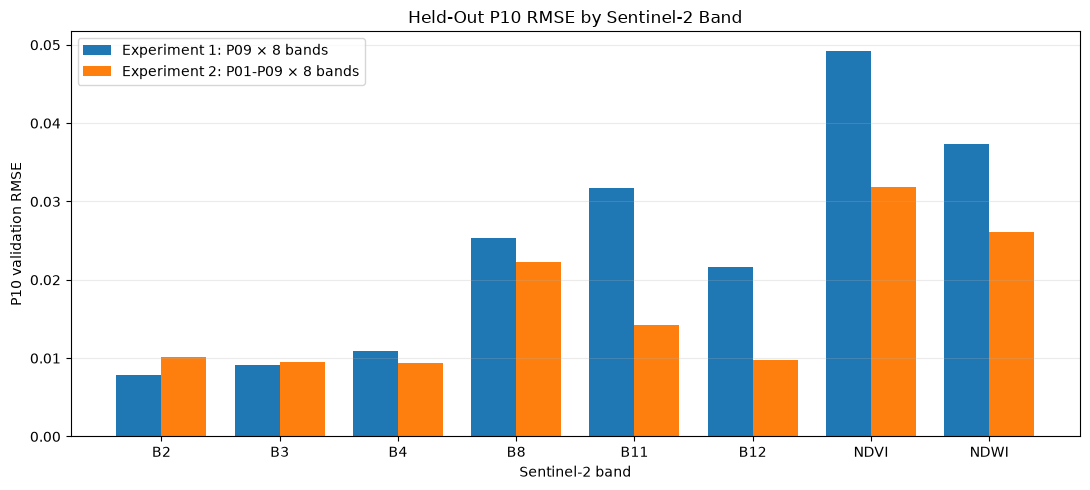


RMSE figure saved:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/scm_mutiple_outcomes/figures/P10_validation_RMSE_by_band.png

RMSE values:
band  P09_8bands  P01_P09_8bands
  B2    0.007850        0.010115
  B3    0.009161        0.009573
  B4    0.010968        0.009411
  B8    0.025374        0.022292
 B11    0.031761        0.014178
 B12    0.021642        0.009712
NDVI    0.049260        0.031845
NDWI    0.037324        0.026114


In [32]:
# =============================================================================
# 31 PLOT P10 VALIDATION RMSE BY SENTINEL-2 BAND
#
# Compare:
#
#   Experiment 1:
#       P09 × 8 bands -> weights
#
#   Experiment 2:
#       P01-P09 × 8 bands -> weights
#
# Both are evaluated on held-out P10.
# =============================================================================

rmse_plot = (
    exp1_summary[
        [
            "band",
            "validation_rmse",
        ]
    ]
    .rename(
        columns={
            "validation_rmse":
                "P09_8bands"
        }
    )
    .merge(
        exp2_summary[
            [
                "band",
                "validation_rmse",
            ]
        ]
        .rename(
            columns={
                "validation_rmse":
                    "P01_P09_8bands"
            }
        ),
        on="band",
        how="outer",
    )
)


# Keep bands in the intended Sentinel-2 order.
rmse_plot[
    "band"
] = pd.Categorical(
    rmse_plot[
        "band"
    ],
    categories=SENSOR_BANDS,
    ordered=True,
)


rmse_plot = (
    rmse_plot
    .sort_values(
        "band"
    )
    .reset_index(
        drop=True
    )
)


# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------

x = np.arange(
    len(
        rmse_plot
    )
)


width = 0.38


fig, ax = plt.subplots(
    figsize=(
        11,
        5,
    )
)


ax.bar(
    x - width / 2,
    rmse_plot[
        "P09_8bands"
    ],
    width,
    label=
        "Experiment 1: P09 × 8 bands",
)


ax.bar(
    x + width / 2,
    rmse_plot[
        "P01_P09_8bands"
    ],
    width,
    label=
        "Experiment 2: P01-P09 × 8 bands",
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    rmse_plot[
        "band"
    ]
)


ax.set_xlabel(
    "Sentinel-2 band"
)


ax.set_ylabel(
    "P10 validation RMSE"
)


ax.set_title(
    "Held-Out P10 RMSE by Sentinel-2 Band"
)


ax.legend()


ax.grid(
    axis="y",
    alpha=0.25,
)


fig.tight_layout()


# -------------------------------------------------------------------------
# Save figure
# -------------------------------------------------------------------------

RMSE_FIGURE_FILE = (
    FIGURE_DIR /
    "P10_validation_RMSE_by_band.png"
)


fig.savefig(
    RMSE_FIGURE_FILE,
    dpi=200,
    bbox_inches="tight",
)


plt.show()


print(
    "\nRMSE figure saved:"
)


print(
    RMSE_FIGURE_FILE
)


print(
    "\nRMSE values:"
)


print(
    rmse_plot.to_string(
        index=False
    )
)